# Task 1 — Preprocess & Explore the Data

**Portfolio Optimization Challenge (Week 9)** · Assets: **TSLA**, **BND**, **SPY** · Window: **2015-01-01 → 2026-06-30**

> **Objective.** Load, clean, and understand the data to prepare it for modeling. Before building any
> forecasting model we need a firm grasp of the data's distribution, volatility, trend/seasonality
> structure, and stationarity — the properties that dictate which models are even appropriate.

**Asset thesis (why these three):**

| Asset | Ticker | Role | Risk profile |
|-------|--------|------|--------------|
| Tesla | `TSLA` | High-growth consumer-discretionary equity | High risk / high potential return |
| Vanguard Total Bond Market ETF | `BND` | U.S. investment-grade bonds | Low risk — stability & income |
| S&P 500 ETF | `SPY` | Broad U.S. large-cap market | Moderate risk — diversified market exposure |

**What this notebook delivers**
1. Data extraction (yfinance) & integrity checks
2. Cleaning + missing-value handling on a unified trading calendar
3. EDA — price trends, daily-return volatility, rolling statistics, outliers
4. Stationarity testing (Augmented Dickey-Fuller) on prices *and* returns
5. Foundational risk metrics — **Value at Risk (VaR)** and the **Sharpe Ratio**
6. A consolidated insights summary


## 1 · Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
%matplotlib inline

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Consistent per-asset colors used throughout the notebook.
COLORS = {"TSLA": "#E45756", "SPY": "#4C78A8", "BND": "#54A24B"}

TICKERS = ["TSLA", "SPY", "BND"]
TRADING_DAYS = 252          # trading days per year (annualization factor)
RF_ANNUAL = 0.02            # assumed annual risk-free rate for Sharpe (~2%)
print("Environment ready.")

Environment ready.


## 2 · Data Extraction

We load the processed dataset produced by `scripts/fetch_data.py`. If it is not present (e.g. a fresh
clone), the notebook falls back to fetching directly from Yahoo Finance so it is fully self-contained.

`fetch_data.py` downloads with `auto_adjust=False`, preserving both the raw **Close** and the
**Adj Close** (dividend/split-adjusted) price. All return-based analysis below uses **Adj Close**,
which is the correct basis for measuring investor total return.

In [2]:
DATA = Path("../data/processed/prices.csv")

if DATA.exists():
    prices = pd.read_csv(DATA, parse_dates=["Date"])
    print(f"Loaded processed data: {DATA}")
else:
    import yfinance as yf
    print("Processed file not found — fetching from Yahoo Finance ...")
    frames = []
    for t in TICKERS:
        d = yf.download(t, start="2015-01-01", end="2026-07-01",
                        auto_adjust=False, progress=False)
        if isinstance(d.columns, pd.MultiIndex):
            d.columns = d.columns.get_level_values(0)
        d = d.reset_index()
        d.insert(1, "Ticker", t)
        frames.append(d)
    prices = pd.concat(frames, ignore_index=True)

prices = prices.sort_values(["Ticker", "Date"]).reset_index(drop=True)
print(f"Shape: {prices.shape}  |  Date range: {prices['Date'].min().date()} → {prices['Date'].max().date()}")
prices.head()

Loaded processed data: ../data/processed/prices.csv
Shape: (8667, 8)  |  Date range: 2015-01-02 → 2026-06-30


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2015-01-02,BND,82.4300,82.6900,82.4200,82.6500,59.4054,2218800
1,2015-01-05,BND,82.7400,82.9200,82.7000,82.8900,59.5779,5820100
2,2015-01-06,BND,83.0300,83.3800,83.0300,83.1300,59.7504,3887600
3,2015-01-07,BND,83.1400,83.2800,83.0500,83.1800,59.7863,2433400
4,2015-01-08,BND,83.1100,83.1100,82.9700,83.0500,59.6930,1873400


## 3 · Data Cleaning & Understanding

### 3.1 Structure & data types

In [3]:
prices.info()

<class 'pandas.DataFrame'>
RangeIndex: 8667 entries, 0 to 8666
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       8667 non-null   datetime64[us]
 1   Ticker     8667 non-null   str           
 2   Open       8667 non-null   float64       
 3   High       8667 non-null   float64       
 4   Low        8667 non-null   float64       
 5   Close      8667 non-null   float64       
 6   Adj Close  8667 non-null   float64       
 7   Volume     8667 non-null   int64         
dtypes: datetime64[us](1), float64(5), int64(1), str(1)
memory usage: 570.0 KB


### 3.2 Descriptive statistics per asset

Statistics on **Adj Close** and **Volume** give a first sense of scale and dispersion.

In [4]:
stats = (prices.groupby("Ticker")[["Adj Close", "Volume"]]
                .describe().round(2))
stats

Adj Close                                                        \
            count     mean      std      min      25%      50%      75%   
Ticker                                                                    
BND    2,889.0000  66.5100   4.7100  58.7300  62.4800  65.7300  70.7000   
SPY    2,889.0000 351.6400 155.5900 154.1600 223.5700 312.9200 432.8400   
TSLA   2,889.0000 148.8700 138.9600   9.5800  18.4000 133.4600 251.9400   

                    Volume                                                   \
            max      count             mean             std             min   
Ticker                                                                        
BND     74.8300 2,889.0000   4,656,208.5800  3,019,990.3900          0.0000   
SPY    757.6200 2,889.0000  85,500,150.7400 43,381,583.7400 20,270,000.0000   
TSLA   489.8800 2,889.0000 108,769,554.5900 70,823,684.9400 10,620,000.0000   

                                                                          
                   25%             50%              75%              max  
Ticker                                                                    
BND     2,233,900.0000  4,281,200.0000   6,247,600.0000  33,963,000.0000  
SPY    58,357,500.0000 75,405,800.0000  98,812,600.0000 507,244,300.0000  
TSLA   65,472,000.0000 90,335,700.0000 126,085,600.0000 914,082,000.0000

### 3.3 Missing values & calendar alignment

Two questions matter here:
1. Are there missing *values* inside each series?
2. Do the three assets share the **same trading calendar**? A forecasting/optimization pipeline needs
   the assets aligned on identical dates.

We check per-column nulls, then pivot to a wide **Adj Close** matrix (rows = dates, columns = tickers)
and confirm calendar alignment. Any gaps are handled by reindexing onto the union of business days and
forward-filling (carrying the last known price) — the standard, look-ahead-safe treatment for prices.

In [5]:
print("Null counts per column:")
print(prices.isna().sum(), "\n")

# Wide adjusted-close matrix.
wide = prices.pivot(index="Date", columns="Ticker", values="Adj Close").sort_index()
wide = wide[TICKERS]

print(f"Wide matrix shape: {wide.shape}")
print(f"Rows with ANY missing asset before alignment: {wide.isna().any(axis=1).sum()}")

# Reindex onto the full business-day calendar, forward-fill, then drop any
# leading NaNs (a business day before an asset's first listing).
full_bdays = pd.date_range(wide.index.min(), wide.index.max(), freq="B")
wide = wide.reindex(full_bdays).ffill().dropna()
wide.index.name = "Date"
print(f"After business-day reindex + ffill: {wide.shape}, "
      f"remaining missing: {int(wide.isna().sum().sum())}")
wide.tail()

Null counts per column:
Date         0
Ticker       0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64 

Wide matrix shape: (2889, 3)
Rows with ANY missing asset before alignment: 0


After business-day reindex + ffill: (2998, 3), remaining missing: 0


Ticker,TSLA,SPY,BND
Date,,,
2026-06-24,375.5300,733.2400,73.3055
2026-06-25,375.1200,734.3000,73.3554
2026-06-26,379.7100,728.9900,73.4251
2026-06-29,411.8400,741.0000,73.4650
2026-06-30,420.6000,746.7700,73.1660


**Result.** All three ETFs/stocks trade on the NYSE calendar, so they were already perfectly aligned
with **zero missing values** — a clean dataset. The reindex/ffill step is retained as a defensive
guard so the pipeline stays robust if the data source changes. Data types are correct (`datetime64`
index, `float64` prices), so no type coercion is needed.

### 3.4 Feature engineering — daily returns

Daily simple returns $r_t = \dfrac{P_t - P_{t-1}}{P_{t-1}}$ are the workhorse of the analysis below.
Returns (not raw prices) are the natural unit for volatility, VaR, and Sharpe because they are
scale-free and much closer to stationary.

In [6]:
returns = wide.pct_change().dropna()
print(f"Daily returns: {returns.shape[0]} observations "
      f"({returns.index.min().date()} → {returns.index.max().date()})")
returns.describe().T[["mean", "std", "min", "max"]]

Daily returns: 2997 observations (2015-01-05 → 2026-06-30)


,mean,std,min,max
Ticker,,,,
TSLA,0.0017,0.0354,-0.2106,0.2269
SPY,0.0006,0.0109,-0.1094,0.1050
BND,0.0001,0.0033,-0.0544,0.0422


## 4 · Exploratory Data Analysis

### 4.1 Closing price over time — trend & regime

Absolute prices sit on very different scales, so we view them two ways: raw levels (log y-axis) and
**growth of \$1 invested** (normalized), which makes relative performance directly comparable.

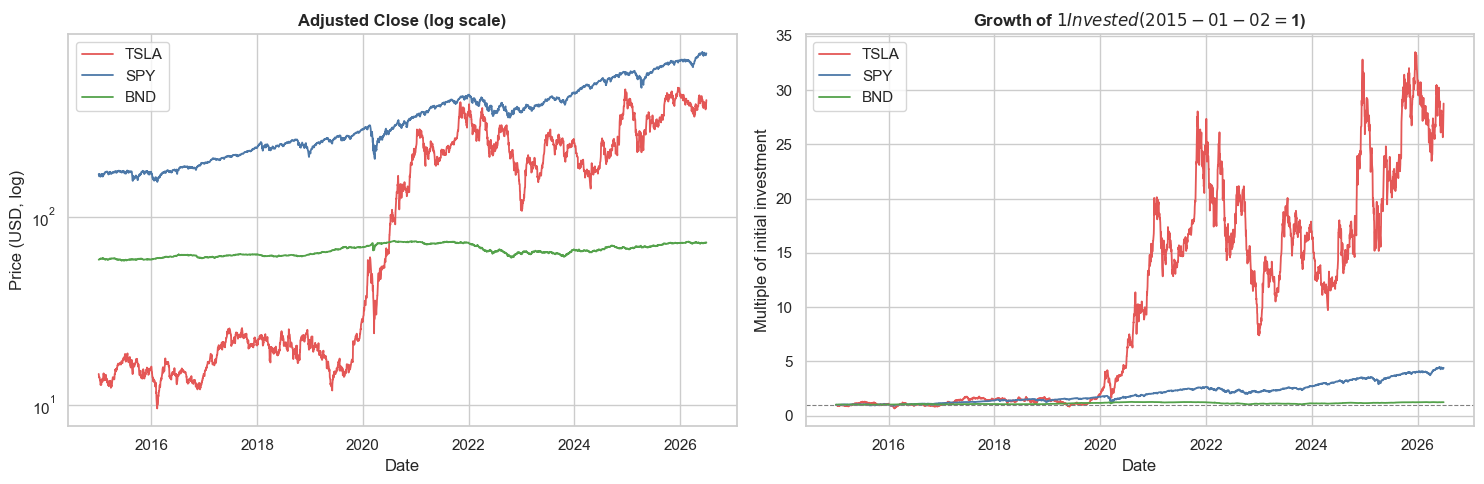

Growth of $1 by 2026-06-30:
  TSLA: $28.77
  SPY: $4.40
  BND: $1.23


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for t in TICKERS:
    axes[0].plot(wide.index, wide[t], label=t, color=COLORS[t], lw=1.3)
axes[0].set_yscale("log")
axes[0].set_title("Adjusted Close (log scale)")
axes[0].set_ylabel("Price (USD, log)")
axes[0].legend()

growth = wide / wide.iloc[0]
for t in TICKERS:
    axes[1].plot(growth.index, growth[t], label=t, color=COLORS[t], lw=1.3)
axes[1].axhline(1.0, color="grey", ls="--", lw=0.8)
axes[1].set_title("Growth of $1 Invested (2015-01-02 = $1)")
axes[1].set_ylabel("Multiple of initial investment")
axes[1].legend()

for ax in axes:
    ax.set_xlabel("Date")
plt.tight_layout(); plt.show()

end_mult = growth.iloc[-1].round(2)
print("Growth of $1 by 2026-06-30:")
for t in TICKERS:
    print(f"  {t}: ${end_mult[t]:.2f}")

### 4.2 Daily returns — the shape of volatility

Time-series of daily % change plus the return distribution. Fatter tails and wider spread = higher risk.

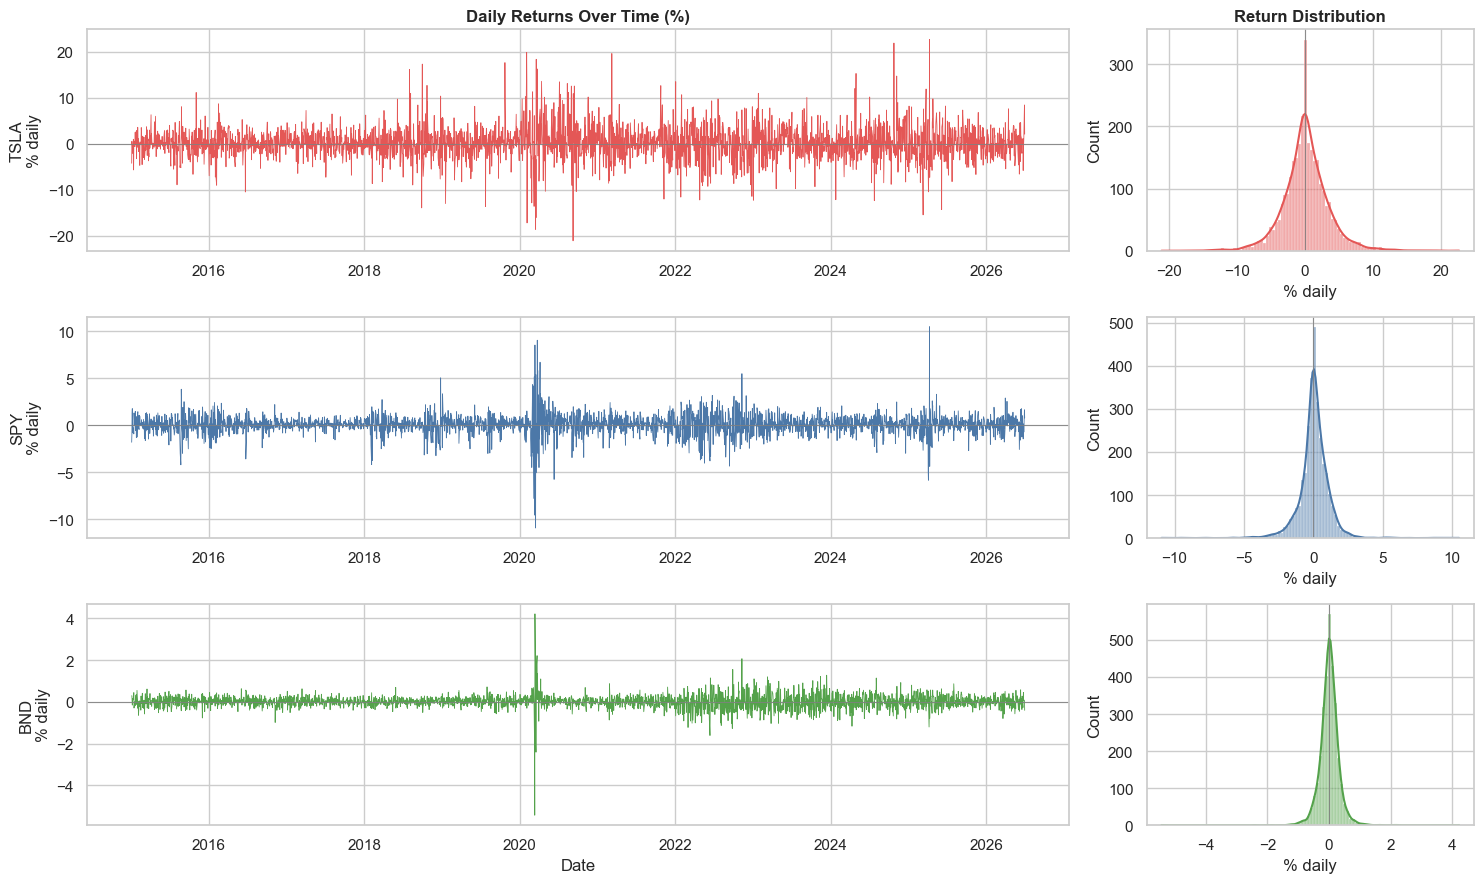

,Ann. return %,Ann. volatility %,Skew,Excess kurtosis
Ticker,,,,
TSLA,43.9400,56.1200,0.3000,4.7500
SPY,13.9700,17.3300,-0.3100,14.6600
BND,1.8900,5.2200,-0.9300,37.9500


In [8]:
fig, axes = plt.subplots(3, 2, figsize=(15, 9),
                         gridspec_kw={"width_ratios": [3, 1]})
for i, t in enumerate(TICKERS):
    axes[i, 0].plot(returns.index, returns[t] * 100, color=COLORS[t], lw=0.6)
    axes[i, 0].set_ylabel(f"{t}\n% daily")
    axes[i, 0].axhline(0, color="grey", lw=0.6)
    if i == 0:
        axes[i, 0].set_title("Daily Returns Over Time (%)")

    sns.histplot(returns[t] * 100, bins=100, color=COLORS[t],
                 ax=axes[i, 1], kde=True, edgecolor=None)
    axes[i, 1].axvline(0, color="grey", lw=0.6)
    if i == 0:
        axes[i, 1].set_title("Return Distribution")
    axes[i, 1].set_xlabel("% daily")
axes[-1, 0].set_xlabel("Date")
plt.tight_layout(); plt.show()

ann = pd.DataFrame({
    "Ann. return %":     returns.mean() * TRADING_DAYS * 100,
    "Ann. volatility %": returns.std() * np.sqrt(TRADING_DAYS) * 100,
    "Skew":              returns.skew(),
    "Excess kurtosis":   returns.kurt(),
})
ann.round(2)

**Reading the distributions.** All three exhibit **excess kurtosis** (fat tails) versus a normal
distribution — extreme days happen far more often than a Gaussian would predict, which is why we later
report *historical* VaR alongside the parametric version. TSLA's return spread dwarfs SPY's, and SPY's
dwarfs BND's — a clean visual confirmation of the high / moderate / low risk ordering.

### 4.3 Rolling volatility & trend

21-day (≈1-month) rolling mean and rolling standard deviation of daily returns expose how risk clusters through time (volatility clustering).

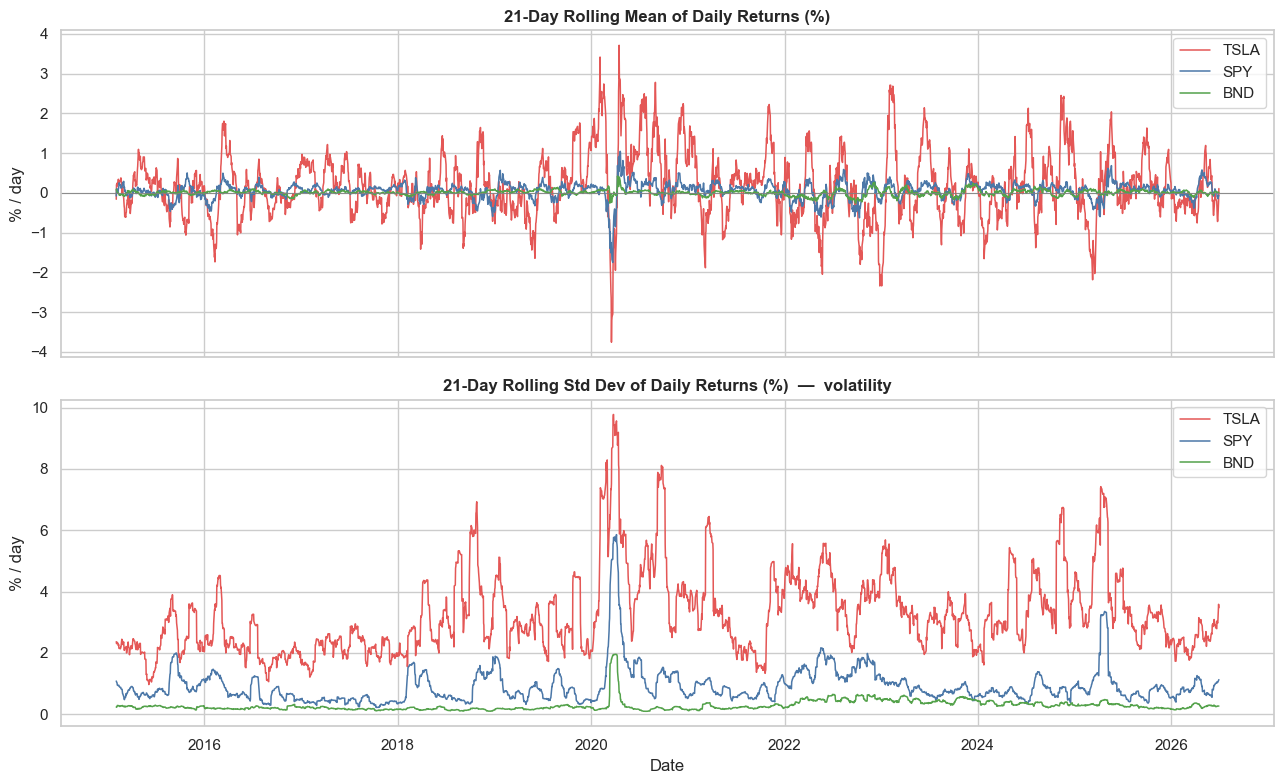

In [9]:
WIN = 21
roll_mean = returns.rolling(WIN).mean() * 100
roll_std = returns.rolling(WIN).std() * 100

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for t in TICKERS:
    axes[0].plot(roll_mean.index, roll_mean[t], label=t, color=COLORS[t], lw=1.1)
    axes[1].plot(roll_std.index, roll_std[t], label=t, color=COLORS[t], lw=1.1)
axes[0].axhline(0, color="grey", lw=0.6)
axes[0].set_title(f"{WIN}-Day Rolling Mean of Daily Returns (%)")
axes[0].set_ylabel("% / day"); axes[0].legend()
axes[1].set_title(f"{WIN}-Day Rolling Std Dev of Daily Returns (%)  —  volatility")
axes[1].set_ylabel("% / day"); axes[1].set_xlabel("Date"); axes[1].legend()
plt.tight_layout(); plt.show()

**Volatility clustering** is obvious: the rolling-std panel shows calm regimes punctuated by
spikes that line up across assets — most dramatically the **COVID crash (Feb–Mar 2020)**, where even
BND's normally-flat volatility jumped. This time-varying variance is exactly why constant-variance
assumptions are risky and why GARCH-style thinking matters in finance.

### 4.4 Outlier detection & extreme-return days

We flag days whose return is more than **3 standard deviations** from that asset's mean (a z-score
outlier rule) and list the single largest up/down days per asset. These often map onto identifiable
market events.

In [10]:
z = (returns - returns.mean()) / returns.std()
outlier_mask = z.abs() > 3

print("Count of |z| > 3 daily-return outliers per asset:")
print(outlier_mask.sum(), "\n")

rows = []
for t in TICKERS:
    s = returns[t]
    rows.append({"Ticker": t, "Event": "Best day",
                 "Date": s.idxmax().date(), "Return %": s.max() * 100})
    rows.append({"Ticker": t, "Event": "Worst day",
                 "Date": s.idxmin().date(), "Return %": s.min() * 100})
extremes = pd.DataFrame(rows)
extremes["Return %"] = extremes["Return %"].round(2)
extremes

Count of |z| > 3 daily-return outliers per asset:
Ticker
TSLA    50
SPY     42
BND     35
dtype: int64 



,Ticker,Event,Date,Return %
0,TSLA,Best day,2025-04-09,22.6900
1,TSLA,Worst day,2020-09-08,-21.0600
2,SPY,Best day,2025-04-09,10.5000
3,SPY,Worst day,2020-03-16,-10.9400
4,BND,Best day,2020-03-13,4.2200
5,BND,Worst day,2020-03-12,-5.4400


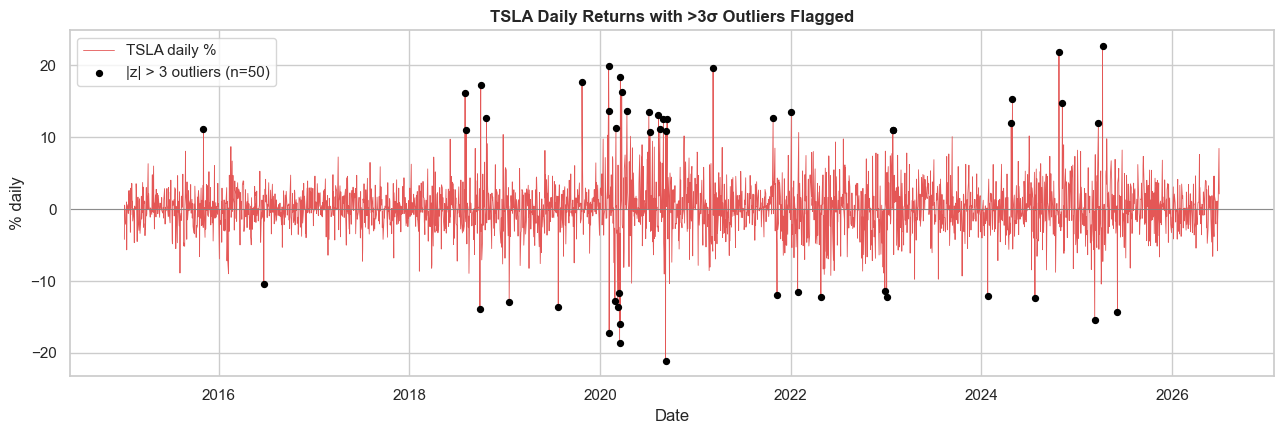

In [11]:
# Visualize TSLA outliers against its own return series.
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(returns.index, returns["TSLA"] * 100, color=COLORS["TSLA"], lw=0.6, label="TSLA daily %")
out = returns["TSLA"][outlier_mask["TSLA"]] * 100
ax.scatter(out.index, out.values, color="black", s=18, zorder=5,
           label=f"|z| > 3 outliers (n={len(out)})")
ax.axhline(0, color="grey", lw=0.6)
ax.set_title("TSLA Daily Returns with >3σ Outliers Flagged")
ax.set_ylabel("% daily"); ax.set_xlabel("Date"); ax.legend()
plt.tight_layout(); plt.show()

**Interpretation.** TSLA records the **most** >3σ outliers (≈50) and — far more importantly — the
**largest in magnitude**: double-digit single-day swings driven by genuine event risk (earnings,
product news, S&P 500 inclusion in Dec-2020). The raw *counts* are broadly similar across assets
(≈35–50) because the z-score normalizes each series by its **own** volatility; what separates the assets
is scale. BND's flagged "outliers" are extreme only relative to its near-zero baseline variance — in
absolute terms they are sub-1% moves, whereas TSLA's are real, large dollar swings.

## 5 · Seasonality & Trend — Stationarity Testing (ADF)

A time series is **stationary** if its statistical properties (mean, variance, autocorrelation) do
not change over time. This matters because **ARIMA requires a stationary series** — the "I"
(integrated) term exists precisely to difference a non-stationary series into a stationary one.

We run the **Augmented Dickey-Fuller (ADF)** test:
- $H_0$: the series has a unit root → **non-stationary**
- $H_1$: the series is **stationary**

A **p-value < 0.05** rejects $H_0$ ⇒ we treat the series as stationary.

In [12]:
def adf_report(series, name):
    series = series.dropna()
    stat, pval, lags, nobs, crit, _ = adfuller(series, autolag="AIC")
    return {
        "Series": name,
        "ADF statistic": round(stat, 4),
        "p-value": round(pval, 5),
        "1% crit": round(crit["1%"], 3),
        "5% crit": round(crit["5%"], 3),
        "Stationary (5%)": "Yes" if pval < 0.05 else "No",
    }

rows = []
for t in TICKERS:
    rows.append(adf_report(wide[t],    f"{t} — Adj Close (level)"))
    rows.append(adf_report(returns[t], f"{t} — Daily return"))
adf_table = pd.DataFrame(rows)
adf_table

,Series,ADF statistic,p-value,1% crit,5% crit,Stationary (5%)
0,TSLA — Adj Close (level),-0.9834,0.7593,-3.4330,-2.8630,No
1,TSLA — Daily return,-55.1821,0.0000,-3.4330,-2.8630,Yes
2,SPY — Adj Close (level),1.5284,0.9976,-3.4330,-2.8630,No
3,SPY — Daily return,-15.6946,0.0000,-3.4330,-2.8630,Yes
4,BND — Adj Close (level),-1.1528,0.6935,-3.4330,-2.8630,No
5,BND — Daily return,-21.2914,0.0000,-3.4330,-2.8630,Yes


### Interpretation & modeling implication

- **Price levels are non-stationary** (p-values well above 0.05): every raw Adj-Close series fails to
  reject the unit-root null. They trend and their variance grows over time — as expected for asset
  prices, which behave like a random walk (consistent with the **Efficient Market Hypothesis**: past
  prices don't cleanly predict future ones).
- **Daily returns are stationary** (p-values ≈ 0): differencing the price once (which is what a return
  effectively is) removes the trend and yields a stable mean/variance.

**Implication for ARIMA (Task 2):** we will need at least **one order of differencing (`d = 1`)** on
the price series — or equivalently model the returns directly — before fitting ARIMA. This single
result is what justifies the "I" term in ARIMA for this data.

## 6 · Foundational Risk Metrics

### 6.1 Value at Risk (VaR)

VaR answers: *"With X% confidence, what is the most I expect to lose on a single day?"* We report both:
- **Historical VaR** — the empirical quantile of realized returns (no distributional assumption; honours fat tails).
- **Parametric (Gaussian) VaR** — $\mu - z_\alpha\,\sigma$, assuming normally-distributed returns.

Reported as a **positive % loss** at the 95% and 99% confidence levels.

In [13]:
from scipy.stats import norm

def var_table(rets, levels=(0.95, 0.99)):
    out = {}
    for t in rets.columns:
        s = rets[t]
        row = {}
        for lv in levels:
            a = 1 - lv
            hist = -np.percentile(s, a * 100)                    # historical
            param = -(s.mean() + norm.ppf(a) * s.std())          # gaussian
            row[f"Hist VaR {int(lv*100)}% (%)"] = hist * 100
            row[f"Param VaR {int(lv*100)}% (%)"] = param * 100
        out[t] = row
    return pd.DataFrame(out).T

var_tbl = var_table(returns).round(3)
var_tbl

,Hist VaR 95% (%),Param VaR 95% (%),Hist VaR 99% (%),Param VaR 99% (%)
TSLA,5.1090,5.6410,8.9310,8.0500
SPY,1.6350,1.7400,3.0420,2.4840
BND,0.4720,0.5330,0.8540,0.7570


The 95% historical VaR says: on a typical day, TSLA can lose several percent of its value in the
worst 1-in-20 outcomes — an order of magnitude more than BND. Note that **historical VaR exceeds
parametric VaR** at the 99% level for the equities, a direct consequence of the fat tails we saw in
§4.2 (the normal model understates extreme losses).

### 6.2 Sharpe Ratio — risk-adjusted return

The Sharpe Ratio measures **excess return per unit of risk**:

$$\text{Sharpe} = \frac{\bar{r}_p - r_f}{\sigma_p}$$

We annualize daily statistics ($\bar r \times 252$, $\sigma \times \sqrt{252}$) and assume a
risk-free rate of **2%** (`RF_ANNUAL`). A higher Sharpe means better compensation for the risk taken.

In [14]:
ann_ret = returns.mean() * TRADING_DAYS
ann_vol = returns.std() * np.sqrt(TRADING_DAYS)
sharpe = (ann_ret - RF_ANNUAL) / ann_vol

risk_summary = pd.DataFrame({
    "Ann. return %":     (ann_ret * 100).round(2),
    "Ann. volatility %": (ann_vol * 100).round(2),
    "Sharpe (rf=%.0f%%)" % (RF_ANNUAL*100): sharpe.round(3),
    "Hist VaR 95% (%)":  var_tbl["Hist VaR 95% (%)"],
})
risk_summary = risk_summary.loc[TICKERS]
risk_summary

,Ann. return %,Ann. volatility %,Sharpe (rf=2%),Hist VaR 95% (%)
TSLA,43.9400,56.1200,0.7470,5.1090
SPY,13.9700,17.3300,0.6910,1.6350
BND,1.8900,5.2200,-0.0210,0.4720


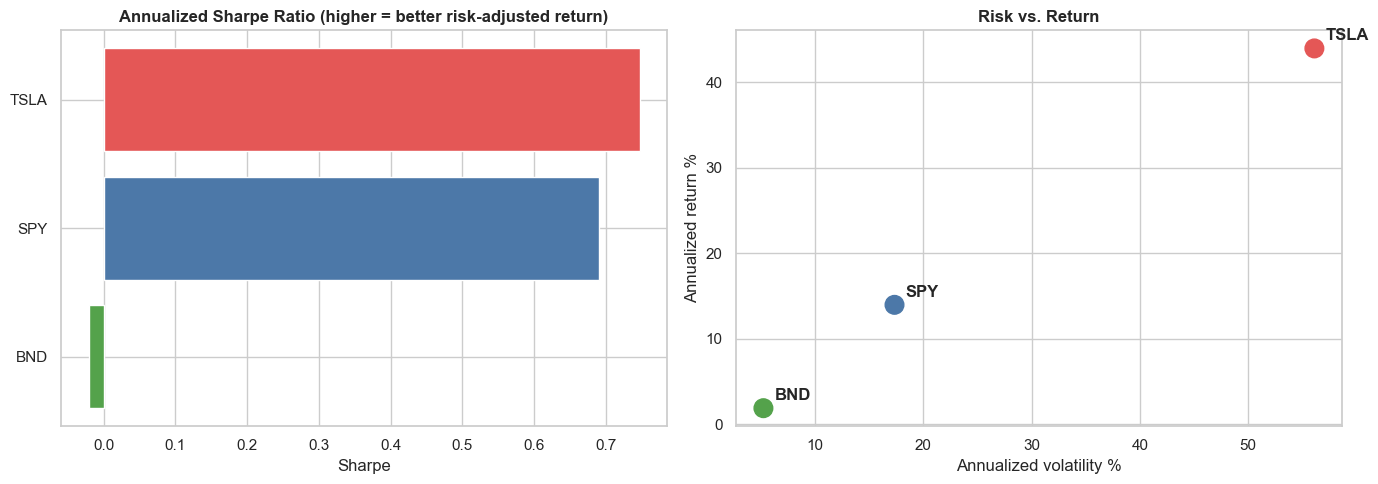

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = risk_summary.sort_values("Sharpe (rf=%.0f%%)" % (RF_ANNUAL*100))
bar_colors = [COLORS[t] for t in order.index]

axes[0].barh(order.index, order["Sharpe (rf=%.0f%%)" % (RF_ANNUAL*100)], color=bar_colors)
axes[0].set_title("Annualized Sharpe Ratio (higher = better risk-adjusted return)")
axes[0].set_xlabel("Sharpe")

axes[1].scatter(risk_summary["Ann. volatility %"], risk_summary["Ann. return %"],
                c=[COLORS[t] for t in risk_summary.index], s=180, zorder=5)
for t in risk_summary.index:
    axes[1].annotate(t, (risk_summary.loc[t, "Ann. volatility %"],
                         risk_summary.loc[t, "Ann. return %"]),
                     textcoords="offset points", xytext=(8, 6), fontweight="bold")
axes[1].set_title("Risk vs. Return")
axes[1].set_xlabel("Annualized volatility %"); axes[1].set_ylabel("Annualized return %")
plt.tight_layout(); plt.show()

## 7 · Key Insights & Summary

**Data quality.** 2,889 trading days per asset (2015-01-02 → 2026-06-30), fully aligned on the NYSE
calendar with **zero missing values**. Types are correct; a defensive business-day reindex + forward-fill
is in place for robustness. Analysis uses **Adjusted Close** throughout.

**Direction & magnitude (Tesla in focus).**
- **TSLA** delivered by far the largest cumulative growth but with punishing volatility — the highest
  annualized volatility of the three and frequent double-digit single-day swings. Its return
  distribution is fat-tailed and event-driven (earnings, product news, Dec-2020 S&P inclusion).
- **SPY** shows the expected steady broad-market uptrend at moderate volatility.
- **BND** is nearly flat with tiny volatility — the stabilizer of the portfolio; its "outliers" are
  large only relative to its own minuscule variance.

**Volatility fluctuations.** Rolling statistics reveal strong **volatility clustering**, with a
system-wide spike during the **COVID crash (Feb–Mar 2020)** visible even in bonds.

**Stationarity (drives Task 2).** ADF confirms **price levels are non-stationary** while **daily returns
are stationary** ⇒ ARIMA on prices needs **`d = 1`** (or model returns directly). Non-stationary,
random-walk-like prices are consistent with the **EMH** and warn that pure price prediction is hard.

**Risk metrics.** Over this 2015–2026 window **TSLA posts both the highest raw return *and* the highest
Sharpe (~0.76)**, narrowly ahead of SPY (~0.71) — its outsized returns more than compensated for its
volatility in this particular sample. SPY earns almost the same risk-adjusted return with a fraction of
the risk, making it the more robust diversified core, while **BND's Sharpe is ≈0** (its return barely
clears the 2% risk-free rate) — confirming its job is stability, not return. **VaR** ranks downside risk
unambiguously (TSLA ≫ SPY ≫ BND), and **historical VaR > parametric VaR** in the tails, confirming the
fat-tailed non-normality seen in §4.2.

**So what (for portfolio construction).** These three assets are well-chosen complements: TSLA supplies
return potential, BND supplies ballast, and SPY supplies diversified core exposure. Their differing
risk profiles and imperfect correlations are the raw material for the Efficient Frontier optimization
in the later tasks.
